In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("../data/heart.csv")
df.head()import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Display plots inside the notebook
%matplotlib inline

In [4]:
df = pd.read_csv("../data/heart.csv")

In [5]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,condition
0,69,1,0,160,234,1,2,131,0,0.1,1,1,0,0
1,69,0,0,140,239,0,0,151,0,1.8,0,2,0,0
2,66,0,0,150,226,0,0,114,0,2.6,2,0,0,0
3,65,1,0,138,282,1,2,174,0,1.4,1,1,0,1
4,64,1,0,110,211,0,2,144,1,1.8,1,0,0,0


In [1]:
)

'C:\\Users\\rojal\\Desktop\\HeartDiseasePrediction\\notebooks'

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("../data/heart.csv")
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,condition
0,69,1,0,160,234,1,2,131,0,0.1,1,1,0,0
1,69,0,0,140,239,0,0,151,0,1.8,0,2,0,0
2,66,0,0,150,226,0,0,114,0,2.6,2,0,0,0
3,65,1,0,138,282,1,2,174,0,1.4,1,1,0,1
4,64,1,0,110,211,0,2,144,1,1.8,1,0,0,0


In [2]:
df.shape

(297, 14)

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 297 entries, 0 to 296
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   age        297 non-null    int64  
 1   sex        297 non-null    int64  
 2   cp         297 non-null    int64  
 3   trestbps   297 non-null    int64  
 4   chol       297 non-null    int64  
 5   fbs        297 non-null    int64  
 6   restecg    297 non-null    int64  
 7   thalach    297 non-null    int64  
 8   exang      297 non-null    int64  
 9   oldpeak    297 non-null    float64
 10  slope      297 non-null    int64  
 11  ca         297 non-null    int64  
 12  thal       297 non-null    int64  
 13  condition  297 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 32.6 KB


In [4]:
df.isnull().sum()

age          0
sex          0
cp           0
trestbps     0
chol         0
fbs          0
restecg      0
thalach      0
exang        0
oldpeak      0
slope        0
ca           0
thal         0
condition    0
dtype: int64

In [5]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,condition
count,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000
mean,54.542088,0.676768,2.158249,131.693603,247.350168,0.144781,0.996633,149.599327,0.326599,1.055556,0.602694,0.676768,0.835017,0.461279
std,9.049736,0.468500,0.964859,17.762806,51.997583,0.352474,0.994914,22.941562,0.469761,1.166123,0.618187,0.938965,0.956690,0.499340
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,2.000000,120.000000,211.000000,0.000000,0.000000,133.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,56.000000,1.000000,2.000000,130.000000,243.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,0.000000,0.000000
75%,61.000000,1.000000,3.000000,140.000000,276.000000,0.000000,2.000000,166.000000,1.000000,1.600000,1.000000,1.000000,2.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,3.000000,2.000000,1.000000


In [6]:
df["condition"].value_counts()

condition
0    160
1    137
Name: count, dtype: int64

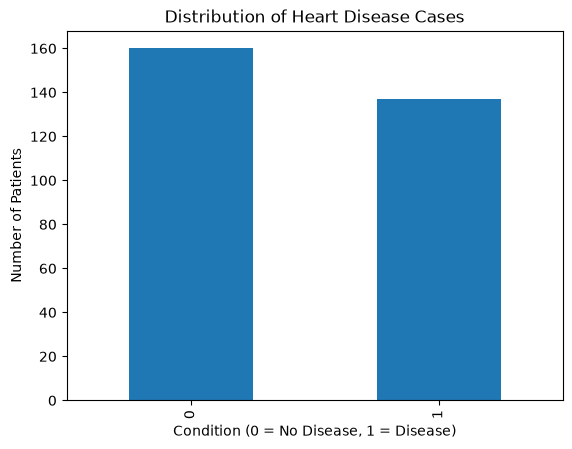

In [7]:
df["condition"].value_counts().plot(kind="bar")

plt.title("Distribution of Heart Disease Cases")
plt.xlabel("Condition (0 = No Disease, 1 = Disease)")
plt.ylabel("Number of Patients")

plt.show()

In [8]:
X = df.drop("condition", axis=1)
y = df["condition"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (297, 13)
Target shape: (297,)


In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (237, 13)
Testing set: (60, 13)


In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [11]:
print(X_train_scaled.shape)
print(X_test_scaled.shape)

(237, 13)
(60, 13)


In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Create the model
lr_model = LogisticRegression(random_state=42)

# Train the model
lr_model.fit(X_train_scaled, y_train)

# Make predictions
y_pred_lr = lr_model.predict(X_test_scaled)

# Accuracy
accuracy_lr = accuracy_score(y_test, y_pred_lr)

print("Logistic Regression Accuracy:", accuracy_lr)

Logistic Regression Accuracy: 0.9166666666666666


In [13]:
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.86      1.00      0.93        32
           1       1.00      0.82      0.90        28

    accuracy                           0.92        60
   macro avg       0.93      0.91      0.91        60
weighted avg       0.93      0.92      0.92        60



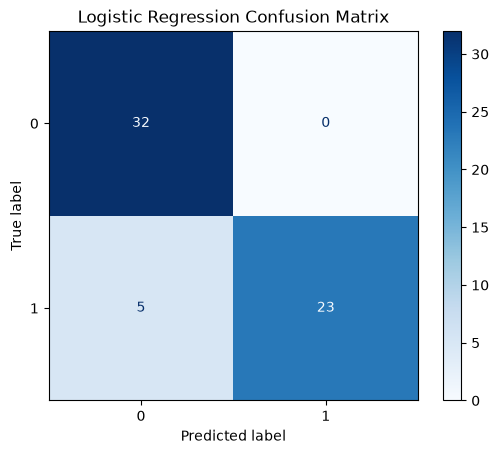

In [14]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(
    lr_model,
    X_test_scaled,
    y_test,
    cmap="Blues"
)

plt.title("Logistic Regression Confusion Matrix")
plt.show()

In [15]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

# Create model
dt_model = DecisionTreeClassifier(random_state=42)

# Train model
dt_model.fit(X_train, y_train)

# Predict
y_pred_dt = dt_model.predict(X_test)

# Accuracy
accuracy_dt = accuracy_score(y_test, y_pred_dt)

print("Decision Tree Accuracy:", accuracy_dt)

Decision Tree Accuracy: 0.7833333333333333


In [16]:
print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       0.77      0.84      0.81        32
           1       0.80      0.71      0.75        28

    accuracy                           0.78        60
   macro avg       0.79      0.78      0.78        60
weighted avg       0.78      0.78      0.78        60



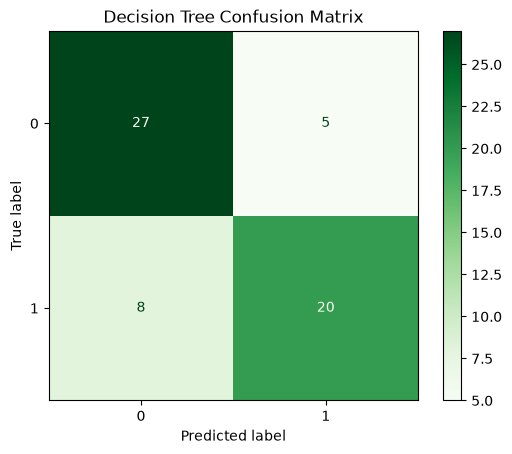

In [17]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_estimator(
    dt_model,
    X_test,
    y_test,
    cmap="Greens"
)

plt.title("Decision Tree Confusion Matrix")
plt.show()

In [18]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Create model
rf_model = RandomForestClassifier(random_state=42)

# Train model
rf_model.fit(X_train, y_train)

# Predict
y_pred_rf = rf_model.predict(X_test)

# Accuracy
accuracy_rf = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", accuracy_rf)

Random Forest Accuracy: 0.8833333333333333


In [19]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.84      0.97      0.90        32
           1       0.96      0.79      0.86        28

    accuracy                           0.88        60
   macro avg       0.90      0.88      0.88        60
weighted avg       0.89      0.88      0.88        60



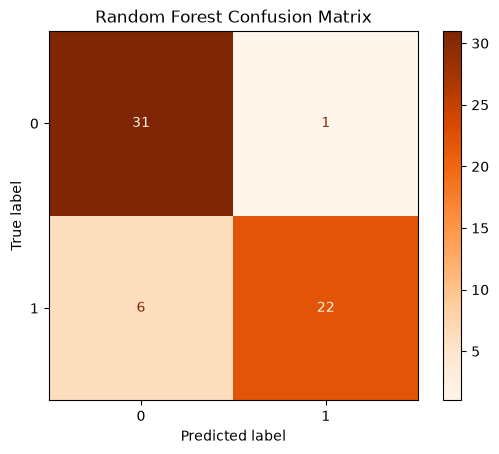

In [20]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_estimator(
    rf_model,
    X_test,
    y_test,
    cmap="Oranges"
)

plt.title("Random Forest Confusion Matrix")
plt.show()

In [21]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

param_grid = {
    "C": [0.01, 0.1, 1, 10, 100],
    "solver": ["liblinear", "lbfgs"]
}

grid_lr = GridSearchCV(
    LogisticRegression(random_state=42),
    param_grid,
    cv=5,
    scoring="accuracy"
)

grid_lr.fit(X_train_scaled, y_train)

print("Best Parameters:", grid_lr.best_params_)
print("Best Cross Validation Score:", grid_lr.best_score_)

Best Parameters: {'C': 0.1, 'solver': 'lbfgs'}
Best Cross Validation Score: 0.8317375886524822


In [22]:
best_lr = grid_lr.best_estimator_

y_pred_best = best_lr.predict(X_test_scaled)

from sklearn.metrics import accuracy_score

print("Tuned Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_best))

Tuned Logistic Regression Accuracy: 0.9166666666666666


In [23]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
import numpy as np

cv_model = LogisticRegression(C=0.1, solver='lbfgs', random_state=42)

cv_scores = cross_val_score(
    cv_model,
    X_train_scaled,
    y_train,
    cv=5,
    scoring="accuracy"
)

print("Cross Validation Scores:", cv_scores)
print("Average Accuracy:", np.mean(cv_scores))

Cross Validation Scores: [0.8125     0.72916667 0.82978723 0.91489362 0.87234043]
Average Accuracy: 0.8317375886524822


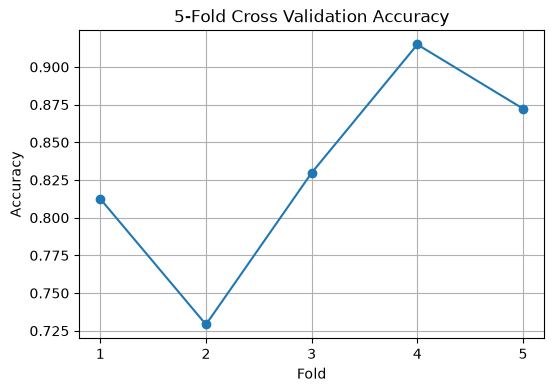

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.plot(range(1,6), cv_scores, marker='o')
plt.title("5-Fold Cross Validation Accuracy")
plt.xlabel("Fold")
plt.ylabel("Accuracy")
plt.xticks(range(1,6))
plt.grid(True)

plt.show()

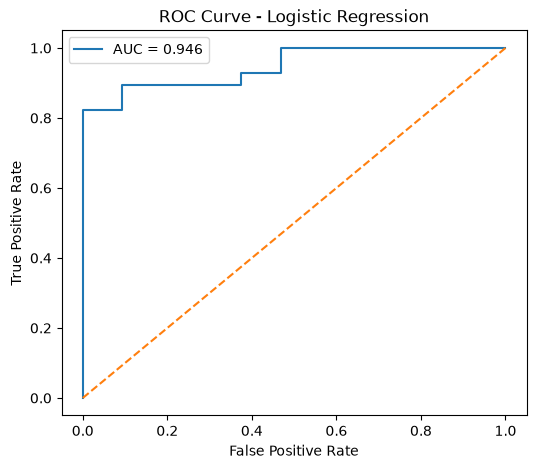

AUC Score: 0.9464285714285715


In [25]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Probability predictions
y_prob = best_lr.predict_proba(X_test_scaled)[:, 1]

# Calculate ROC
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Calculate AUC
auc_score = roc_auc_score(y_test, y_prob)

# Plot
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}")
plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()

plt.show()

print("AUC Score:", auc_score)

In [26]:
import pandas as pd

# Create DataFrame of coefficients
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": best_lr.coef_[0]
})

# Sort by absolute importance
coefficients["Absolute"] = coefficients["Coefficient"].abs()
coefficients = coefficients.sort_values(by="Absolute", ascending=False)

print(coefficients)

# Remove helper column for plotting
plot_data = coefficients.drop(columns="Absolute")

     Feature  Coefficient  Absolute
11        ca     0.702875  0.702875
12      thal     0.482752  0.482752
2         cp     0.404616  0.404616
7    thalach    -0.370474  0.370474
8      exang     0.370307  0.370307
9    oldpeak     0.370149  0.370149
1        sex     0.278922  0.278922
10     slope     0.189630  0.189630
3   trestbps     0.178513  0.178513
5        fbs    -0.140112  0.140112
6    restecg     0.116071  0.116071
4       chol     0.089158  0.089158
0        age     0.028416  0.028416


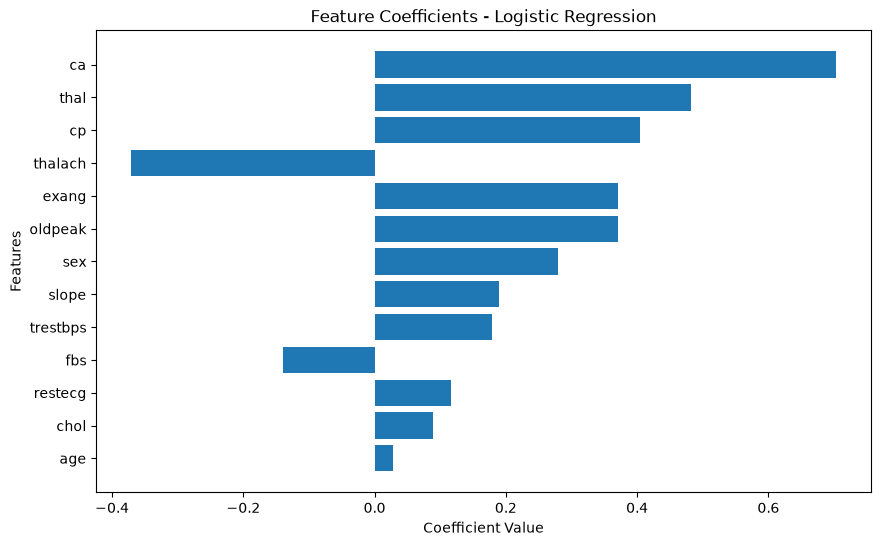

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.barh(plot_data["Feature"], plot_data["Coefficient"])
plt.title("Feature Coefficients - Logistic Regression")
plt.xlabel("Coefficient Value")
plt.ylabel("Features")
plt.gca().invert_yaxis()

plt.show()

In [28]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_lr,
        accuracy_dt,
        accuracy_rf
    ]
})

comparison = comparison.sort_values(
    by="Accuracy",
    ascending=False
)

comparison

,Model,Accuracy
0,Logistic Regression,0.916667
2,Random Forest,0.883333
1,Decision Tree,0.783333


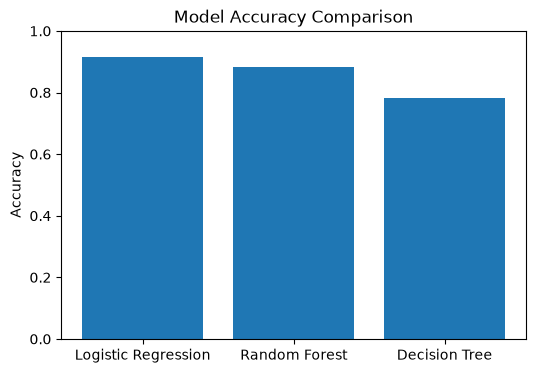

In [29]:
plt.figure(figsize=(6,4))

plt.bar(comparison["Model"], comparison["Accuracy"])

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0,1)

plt.show()

In [30]:
import joblib

# Save the trained model
joblib.dump(best_lr, "../models/logistic_regression_model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [31]:
plt.savefig("../outputs/roc_curve.png", dpi=300, bbox_inches="tight")
plt.show()

<Figure size 640x480 with 0 Axes>

In [32]:
plt.savefig("../outputs/confusion_matrix_lr.png", dpi=300, bbox_inches="tight")
plt.show()

<Figure size 640x480 with 0 Axes>

In [33]:
plt.savefig("../outputs/confusion_matrix_dt.png", dpi=300, bbox_inches="tight")
plt.show()

<Figure size 640x480 with 0 Axes>

In [34]:
plt.savefig("../outputs/confusion_matrix_rf.png", dpi=300, bbox_inches="tight")
plt.show()

<Figure size 640x480 with 0 Axes>

In [35]:
plt.savefig("../outputs/cross_validation.png", dpi=300, bbox_inches="tight")
plt.show()

<Figure size 640x480 with 0 Axes>

In [36]:
plt.savefig("../outputs/feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()

<Figure size 640x480 with 0 Axes>

In [37]:
plt.savefig("../outputs/model_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

<Figure size 640x480 with 0 Axes>